In [21]:
from ISLP import load_data
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize

In [30]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

**15.** \
This problem involves the Boston data set, which we saw in the lab for this chapter.\
We will now try to predict per capita crime rate using the other variables in this data set.\
In other words, per capita crime rate is the response, and the other variables are the predictors

In [22]:
boston = load_data('Boston')
row_count = boston.shape[0]

In [29]:
y = boston['crim']
y.head()

0    0.00632
1    0.02731
2    0.02729
3    0.03237
4    0.06905
Name: crim, dtype: float64

**(a)** For each predictor, fit a simple linear regression model to predict the response. \
Describe your results.\
In which of the models is there a statistically significant association between the predictor and the response? \
Create some plots to back up your assertions.

In [24]:
predictors = list(boston.columns.drop('crim'))
predictors

['zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'lstat',
 'medv']

In [26]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    '% of low-density zoning': boston['zn']})
x.head()

,intercept,% of low-density zoning
0,1.0,18.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


In [28]:
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,4.4537,0.417,10.675,0.0
% of low-density zoning,-0.0739,0.016,-4.594,0.0


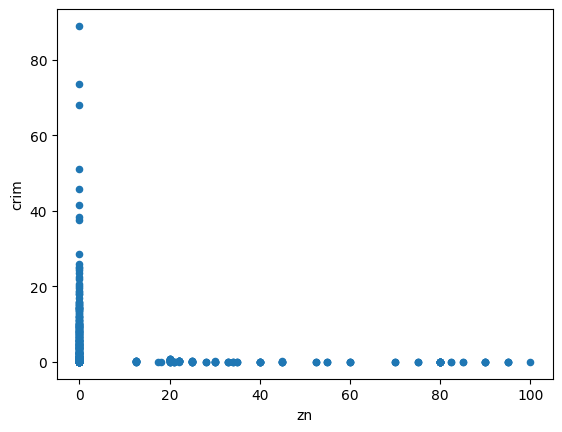

In [33]:
ax = boston.plot.scatter('zn', 'crim')